In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub
!pip install -r requirements.txt

%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
sys.path.insert(0, f"{BASE}/ForensicHub")
sys.path.insert(0, f"{BASE}/DeepfakeBench")
sys.path.insert(0, f"{BASE}/IMDLBenCo")

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is l

In [ ]:
# !pip3 install -q imgaug albumentations==1.3.1 timm einops ftfy regex lmdb fvcore

In [ ]:
%%capture
!pip install -q \
    fvcore \
    iopath \
    timm \
    einops \
    grad-cam \
    albumentations \
    scikit-image \
    kornia \
    yacs \
    segmentation-models-pytorch \
    jpegio

In [ ]:
%%capture
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

In [ ]:
%%capture
%cd "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub"
!head -n -1 requirements.txt > requirements_no_flash.txt
!pip install -r requirements_no_flash.txt

In [ ]:
import os, sys, torch

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
sys.path.insert(0, os.path.join(BASE, "IMDLBenCo"))
from IMDLBenCo.model_zoo.trufor.trufor import Trufor

NP_W      = f"{BASE}/trufor_pretrained/noiseprint.pth"
MIT_W     = f"{BASE}/trufor_pretrained/mit_b2.pth"
CFG_PATH  = f"{BASE}/IMDLBenCo/IMDLBenCo/statics/model_zoo/configs/trufor.yaml"
OFFICIAL  = f"{BASE}/trufor_pretrained/weights/trufor.pth.tar"

teacher = Trufor(phase=2,
                 np_pretrain_weights=NP_W,
                 mit_b2_pretrain_weights=MIT_W,
                 config_path=CFG_PATH)

ckpt  = torch.load(OFFICIAL, map_location="cpu", weights_only=False)
state = ckpt.get("state_dict", ckpt.get("model", ckpt))

cleaned = {}
for k, v in state.items():
    new_k = k
    for pref in ("module.", "_base_model.", "base_model.", "model."):
        if new_k.startswith(pref):
            new_k = new_k[len(pref):]
    cleaned[new_k] = v

missing, unexpected = teacher.model.load_state_dict(cleaned, strict=False)
print(f"missing={len(missing)}  unexpected={len(unexpected)}")
print("missing sample :", missing[:3])
print("unexpected sample:", unexpected[:3])

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Using backbone: Segformer-B2
load noiseprint++ weight success.
load mit_b2 weight success.
missing=0  unexpected=0
missing sample : []
unexpected sample: []


In [ ]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
import os, sys, importlib

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
FORENSICHUB = os.path.join(BASE, "ForensicHub")
DEEPFAKEBENCH = os.path.join(BASE, "DeepfakeBench")
IMDLBENCO = os.path.join(BASE, "IMDLBenCo")

for p in [BASE, FORENSICHUB, DEEPFAKEBENCH, IMDLBENCO]:
    if p not in sys.path:
        sys.path.insert(0, p)

importlib.invalidate_caches()

import ForensicHub.tasks.deepfake
from ForensicHub.registry import MODELS

print("EffortTruforReweight registered:", "EffortTruforReweight" in MODELS)

2.10.0+cu128
Current Torch version: 2.10
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
EffortTruforReweight registered: True


In [ ]:
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

!PYTHONPATH=/content/drive/MyDrive/Capstone_Hripsime/Frameworks:/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub:/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench:/content/drive/MyDrive/Capstone_Hripsime/Frameworks/IMDLBenCo \
MASTER_ADDR=127.0.0.1 MASTER_PORT=29699 \
python -m ForensicHub.training_scripts.train \
    --config "ForensicHub/statics/crossdataset_image/effort_reweight_train.yaml"

/content/drive/.shortcut-targets-by-id/1dhyo0l8QyhlSMCpS1lnpG93K1z7h6d4K/Capstone_Hripsime/Frameworks/ForensicHub
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
/usr/local/lib/python3.12/dist-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2.10.0+cu128
Current Torch version: 2.10
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'groups', 'bias', 'padding_mode', 'device', 'dtype']
spatial_count=0 keep_stride_count=0
['in_channels', 'out_channels', 'kernel_size', 'stride', 'padding', 'dilation', 'grou

Best AUC: 0.7148 at epoch 13
F1 at best AUC epoch: 0.6579 at epoch 13


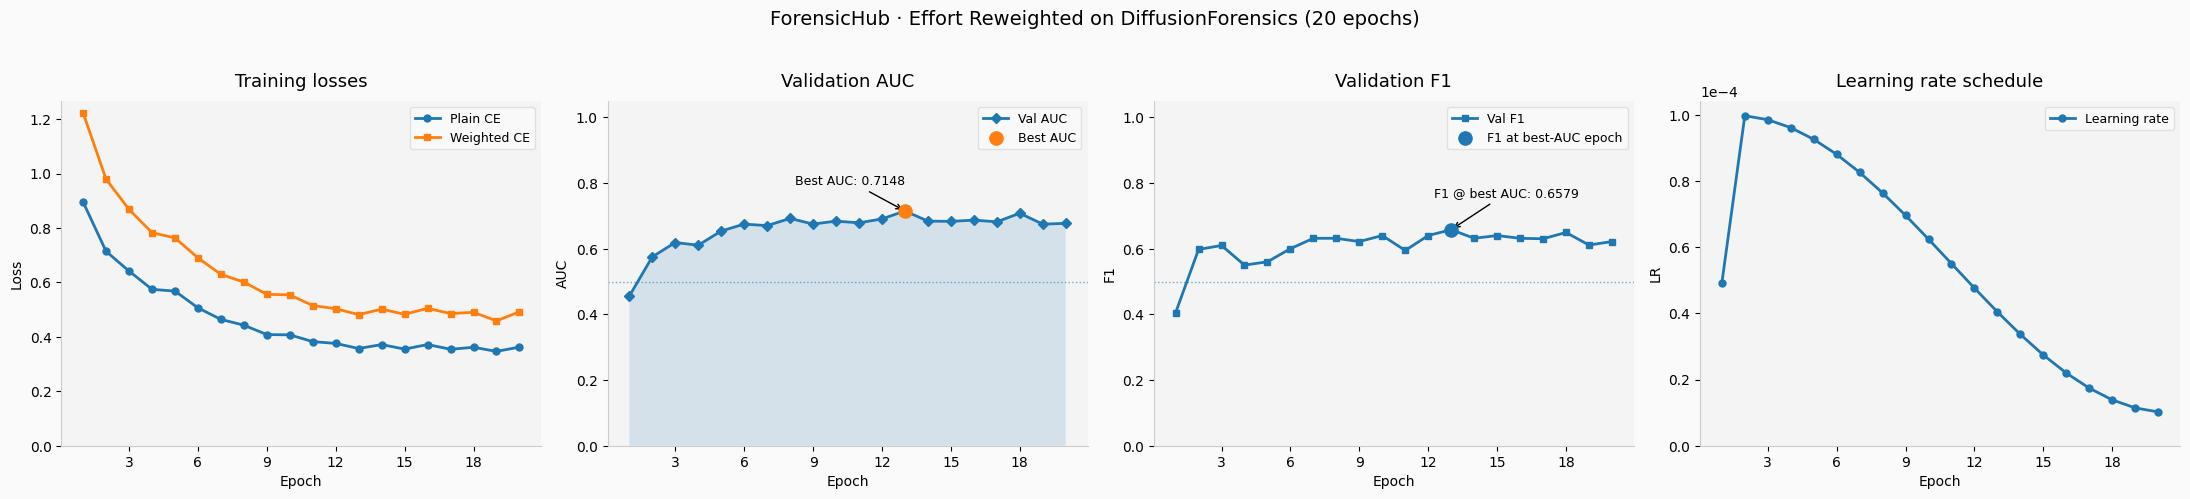

In [4]:
%matplotlib inline
import os, json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import Image, display

LOG_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_reweight_train/log.txt"


def parse_reweighted_effort_log(path):
    all_entries = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in entry:
                all_entries.append(entry)

    if not all_entries:
        raise RuntimeError(f"No JSON epoch entries found in {path}")

    runs = []
    current_run = []
    prev_epoch = -1

    for entry in all_entries:
        ep = int(entry.get("epoch", 0))

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(entry)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    entries = runs[-1]
    epochs = [int(e["epoch"]) + 1 for e in entries]

    plain_ce = [float(e.get("train_ce_plain", np.nan)) for e in entries]
    weighted_ce = [float(e.get("train_ce_weighted", np.nan)) for e in entries]
    mean_w = [float(e.get("train_mean_w", np.nan)) for e in entries]
    mean_p_trufor = [float(e.get("train_mean_p_trufor", np.nan)) for e in entries]
    lrs = [float(e.get("train_lr", np.nan)) for e in entries]
    aucs = [float(e.get("test_image-level AUC", np.nan)) for e in entries]
    f1s = [float(e.get("test_image-level F1", np.nan)) for e in entries]

    return epochs, plain_ce, weighted_ce, mean_w, mean_p_trufor, lrs, aucs, f1s, len(runs)


def plot_reweighted_training(path):
    (
        epochs,
        plain_ce,
        weighted_ce,
        mean_w,
        mean_p_trufor,
        lrs,
        aucs,
        f1s,
        n_runs,
    ) = parse_reweighted_effort_log(path)

    aucs_np = np.array(aucs, dtype=float)
    best_auc_idx = int(np.nanargmax(aucs_np))

    best_auc_epoch = epochs[best_auc_idx]
    best_auc = aucs[best_auc_idx]
    f1_at_best_auc = f1s[best_auc_idx]

    print(f"Best AUC: {best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"F1 at best AUC epoch: {f1_at_best_auc:.4f} at epoch {best_auc_epoch}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8))
    fig.patch.set_facecolor("#FAFAFA")

    for ax in axes:
        ax.set_facecolor("#F4F4F4")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # 1. Training losses
    ax = axes[0]
    ax.plot(epochs, plain_ce, marker="o", linewidth=2, markersize=5, label="Plain CE")
    ax.plot(epochs, weighted_ce, marker="s", linewidth=2, markersize=5, label="Weighted CE")
    ax.set_ylim(bottom=0)
    ax.set_title("Training losses", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9, framealpha=0.5)

    # 2. Validation AUC
    ax = axes[1]
    ax.plot(epochs, aucs, marker="D", linewidth=2, markersize=5, label="Val AUC")
    ax.fill_between(epochs, 0, aucs, alpha=0.15)
    ax.scatter(best_auc_epoch, best_auc, s=90, zorder=5, label="Best AUC")
    ax.annotate(
        f"Best AUC: {best_auc:.4f}",
        xy=(best_auc_epoch, best_auc),
        xytext=(best_auc_epoch - max(epochs) * 0.12, best_auc + 0.08),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation AUC", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC")
    ax.legend(fontsize=9, framealpha=0.5)

    # 3. Validation F1 at best-AUC epoch
    ax = axes[2]
    ax.plot(epochs, f1s, marker="s", linewidth=2, markersize=5, label="Val F1")
    ax.scatter(best_auc_epoch, f1_at_best_auc, s=90, zorder=5, label="F1 at best-AUC epoch")
    ax.annotate(
        f"F1 @ best AUC: {f1_at_best_auc:.4f}",
        xy=(best_auc_epoch, f1_at_best_auc),
        xytext=(best_auc_epoch + max(epochs) * 0.12, f1_at_best_auc + 0.10),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation F1", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.legend(fontsize=9, framealpha=0.5)

    # 4. Learning rate
    ax = axes[3]
    ax.plot(epochs, lrs, marker="o", linewidth=2, markersize=5, label="Learning rate")
    ax.set_ylim(bottom=0)
    ax.set_title("Learning rate schedule", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.legend(fontsize=9, framealpha=0.5)

    plt.suptitle(
        f"ForensicHub · Effort Reweighted on DiffusionForensics ({len(epochs)} epochs)",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()

    out_path = "forensichub_effort_reweighted_training_curves.jpg"
    plt.savefig(out_path, dpi=100, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

    display(Image(out_path))


plot_reweighted_training(LOG_PATH)

Saved: /content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/forensichub_effort_reweighted_training_loss.jpg


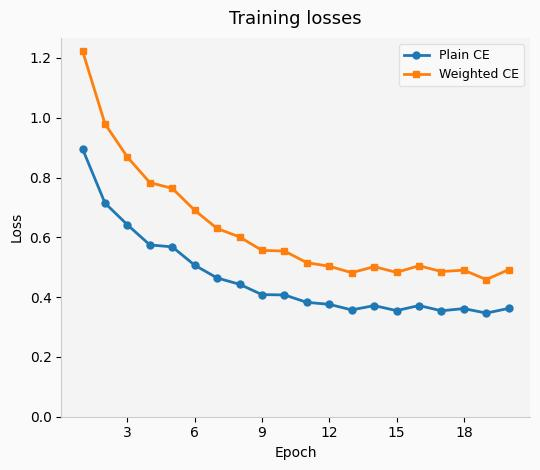

In [5]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import Image, display

LOG_PATH = Path(
    "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_reweight_train/log.txt"
)

FIG_DIR = Path(
    "/content/drive/MyDrive/Capstone_Hripsime/submission/results/figures"
)
FIG_DIR.mkdir(parents=True, exist_ok=True)


def parse_reweighted_effort_log(path):
    all_entries = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in entry:
                all_entries.append(entry)

    if not all_entries:
        raise RuntimeError(f"No JSON epoch entries found in {path}")

    runs = []
    current_run = []
    prev_epoch = -1

    for entry in all_entries:
        ep = int(entry.get("epoch", 0))

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(entry)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    entries = runs[-1]

    epochs = [int(e["epoch"]) + 1 for e in entries]
    plain_ce = [float(e.get("train_ce_plain", np.nan)) for e in entries]
    weighted_ce = [float(e.get("train_ce_weighted", np.nan)) for e in entries]

    return epochs, plain_ce, weighted_ce


def save_exact_training_loss_plot(path):
    epochs, plain_ce, weighted_ce = parse_reweighted_effort_log(path)

    # Same style as the first subplot in your original 4-panel figure
    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    fig.patch.set_facecolor("#FAFAFA")

    ax.set_facecolor("#F4F4F4")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax.plot(
        epochs,
        plain_ce,
        marker="o",
        linewidth=2,
        markersize=5,
        label="Plain CE",
    )
    ax.plot(
        epochs,
        weighted_ce,
        marker="s",
        linewidth=2,
        markersize=5,
        label="Weighted CE",
    )

    ax.set_ylim(bottom=0)
    ax.set_title("Training losses", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9, framealpha=0.5)

    plt.tight_layout()

    out_path = FIG_DIR / "forensichub_effort_reweighted_training_loss.jpg"
    plt.savefig(out_path, dpi=100, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

    print("Saved:", out_path)
    display(Image(filename=str(out_path)))


save_exact_training_loss_plot(LOG_PATH)

In [ ]:
# model
import os
import json
import torch
from PIL import Image
from torchvision import transforms
import sys

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"

sys.path.insert(0, BASE)
sys.path.insert(0, os.path.join(BASE, "ForensicHub"))
sys.path.insert(0, os.path.join(BASE, "DeepfakeBench"))
sys.path.insert(0, os.path.join(BASE, "IMDLBenCo"))

import ForensicHub.tasks.deepfake
from ForensicHub.registry import MODELS, build_from_registry

# ── Paths / constants ─────────────────────────────────────────────────────────
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/crossdataset_image_new/diffusionforensics_effort_reweight_train"
VAL_JSON = "/content/DiffusionForensics_Recons/val.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.5

# ── Step 1: find best epoch automatically from the log ────────────────────────
LOG_PATH = os.path.join(CHECKPOINT_DIR, "log.txt")

all_entries = []
with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            all_entries.append(json.loads(line))
        except Exception:
            continue

runs, current_run, prev_epoch = [], [], -1

for entry in all_entries:
    ep = entry.get("epoch", 0)

    if ep <= prev_epoch and current_run:
        runs.append(current_run)
        current_run = []

    current_run.append(entry)
    prev_epoch = ep

if current_run:
    runs.append(current_run)

if not runs:
    raise RuntimeError(f"No valid log runs found in {LOG_PATH}")

last_run = runs[-1]

# Choose best checkpoint by validation AUC
best_entry = max(last_run, key=lambda e: e["test_image-level AUC"])
best_epoch = int(best_entry["epoch"])
best_auc = float(best_entry["test_image-level AUC"])
best_f1 = float(best_entry.get("test_image-level F1", float("nan")))

print(f"Best epoch from log by AUC: {best_epoch}")
print(f"Best val AUC: {best_auc:.6f}")
print(f"Val F1 at best-AUC epoch: {best_f1:.6f}")

# ── Step 2: select checkpoint ─────────────────────────────────────────────────
best_ckpt = os.path.join(CHECKPOINT_DIR, f"checkpoint-{best_epoch}.pth")

if not os.path.exists(best_ckpt):
    available = sorted(
        [
            f for f in os.listdir(CHECKPOINT_DIR)
            if f.startswith("checkpoint-") and f.endswith(".pth")
        ],
        key=lambda f: int(f.replace("checkpoint-", "").replace(".pth", ""))
    )

    if not available:
        raise FileNotFoundError(f"No checkpoint files found in {CHECKPOINT_DIR}")

    candidates = [
        f for f in available
        if int(f.replace("checkpoint-", "").replace(".pth", "")) <= best_epoch
    ]

    best_ckpt = os.path.join(
        CHECKPOINT_DIR,
        candidates[-1] if candidates else available[-1]
    )

print("Using checkpoint:")
print(best_ckpt)

# ── Step 3: build exact Effort model from ForensicHub registry ────────────────
model_args = {
    "name": "EffortDetector",
    "init_config": {
        "yaml_config_path": f"{BASE}/DeepfakeBench/DeepfakeBench/training/config/config/detector/effort.yaml"
    }
}

model = build_from_registry(MODELS, model_args)

checkpoint = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model"] if "model" in checkpoint else checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

if len(missing) > 0:
    print("First missing keys:", missing[:10])

if len(unexpected) > 0:
    print("First unexpected keys:", unexpected[:10])

model.to(DEVICE)
model.eval()

# ── Step 4: validation transform ──────────────────────────────────────────────
# Must match your Effort YAML:
# image_size: 224
# transform: AIGCTransform
# norm_type: clip

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711],
    ),
])

# ── Step 5: load validation items and run inference ───────────────────────────
with open(VAL_JSON) as f:
    val_items = json.load(f)

results = []
skipped = []

with torch.no_grad():
    for item in val_items:
        path = item["path"]
        label = int(item["label"])

        try:
            image_tensor = val_transform(
                Image.open(path).convert("RGB")
            ).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": image_tensor,
                "label": torch.tensor([label], dtype=torch.long).to(DEVICE),
                "mask": torch.ones(1, 1, 224, 224).to(DEVICE),
            }

            out_dict = model(**input_dict)

            prob = out_dict["pred_label"].view(-1)[0].item()
            pred = 1 if prob >= THRESHOLD else 0

            results.append({
                "path": path,
                "true_label": label,
                "pred": int(pred),
                "confidence": float(prob),
                "correct": bool(pred == label),
            })

        except Exception as e:
            skipped.append({
                "path": path,
                "error": str(e),
            })

if len(results) == 0:
    raise RuntimeError("No validation images were processed successfully.")

print(f"Processed: {len(results)}")
print(f"Skipped: {len(skipped)}")

Best epoch from log by AUC: 12
Best val AUC: 0.714844
Val F1 at best-AUC epoch: 0.657895
Using checkpoint:
/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_reweight_train/checkpoint-12.pth
[lazy import] Loading 'EffortDetector' from 'DeepfakeBench.training.detectors.effort_detector'
[build_from_registry] Creating model 'EffortDetector' with args: {'yaml_config_path': '/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench/DeepfakeBench/training/config/config/detector/effort.yaml'}


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings.class_embedding: False
embeddings.patch_embedding.weight: False
embeddings.position_embedding.weight: False
pre_layrnorm.weight: False
pre_layrnorm.bias: False
encoder.layers.0.self_attn.k_proj.weight_main: False
encoder.layers.0.self_attn.k_proj.bias: False
encoder.layers.0.self_attn.k_proj.S_residual: True
encoder.layers.0.self_attn.k_proj.U_residual: True
encoder.layers.0.self_attn.k_proj.V_residual: True
encoder.layers.0.self_attn.v_proj.weight_main: False
encoder.layers.0.self_attn.v_proj.bias: False
encoder.layers.0.self_attn.v_proj.S_residual: True
encoder.layers.0.self_attn.v_proj.U_residual: True
encoder.layers.0.self_attn.v_proj.V_residual: True
encoder.layers.0.self_attn.q_proj.weight_main: False
encoder.layers.0.self_attn.q_proj.bias: False
encoder.layers.0.self_attn.q_proj.S_residual: True
encoder.layers.0.self_attn.q_proj.U_residual: True
encoder.layers.0.self_attn.q_proj.V_residual: True
encoder.layers.0.self_attn.out_proj.weight_main: False
encoder.layers.0.s

In [ ]:
 # ── Inference on TRAINING set, Effort model already loaded ──
import json
import torch
from PIL import Image
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

TRAIN_JSON = "/content/DiffusionForensics_Recons/train.json"

with open(TRAIN_JSON) as f:
    train_items = json.load(f)

print(f"Running inference on {len(train_items)} training images...")

train_results = []
train_skipped = []

with torch.no_grad():
    for i, item in enumerate(train_items):
        path = item["path"]
        label = int(item["label"])

        try:
            image_tensor = val_transform(
                Image.open(path).convert("RGB")
            ).unsqueeze(0).to(DEVICE)

            input_dict = {
                "image": image_tensor,
                "label": torch.tensor([label], dtype=torch.long).to(DEVICE),
                "mask": torch.ones(1, 1, 224, 224).to(DEVICE),
            }

            out_dict = model(**input_dict)

            prob = out_dict["pred_label"].view(-1)[0].item()
            pred = 1 if prob >= THRESHOLD else 0

            train_results.append({
                "path": path,
                "true_label": label,
                "pred": int(pred),
                "confidence": float(prob),
                "correct": bool(pred == label),
            })

        except Exception as e:
            train_skipped.append({
                "path": path,
                "error": str(e),
            })

        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{len(train_items)} processed | ok={len(train_results)} | skipped={len(train_skipped)}")

if len(train_results) == 0:
    raise RuntimeError("No training images were processed successfully.")

train_labels = np.array([r["true_label"] for r in train_results])
train_scores = np.array([r["confidence"] for r in train_results])
train_preds = np.array([r["pred"] for r in train_results])

train_acc = accuracy_score(train_labels, train_preds)
train_f1 = f1_score(train_labels, train_preds)
train_auc = roc_auc_score(train_labels, train_scores)

print("\n=== Train set results ===")
print(f"Processed: {len(train_results)}")
print(f"Skipped:   {len(train_skipped)}")
print(f"Train accuracy: {train_acc * 100:.2f}%")
print(f"Train F1:       {train_f1:.4f}")
print(f"Train AUC:      {train_auc:.4f}")

Running inference on 1000 training images...
  500/1000 processed | ok=500 | skipped=0
  1000/1000 processed | ok=1000 | skipped=0

=== Train set results ===
Processed: 1000
Skipped:   0
Train accuracy: 87.60%
Train F1:       0.8681
Train AUC:      0.9425


════════════════════════════════════════════════════════════
  Validation Metrics
════════════════════════════════════════════════════════════
  Best epoch selected by validation AUC: 13
  Logged AUC at best epoch:             0.7148
  Logged F1 at best-AUC epoch:          0.6579
  Accuracy: 0.7200
────────────────────────────────────────────────────────────
  TP (correct fake): 25
  TN (correct real): 47
  FP (false alarm):  3
  FN (missed fake):  25
════════════════════════════════════════════════════════════


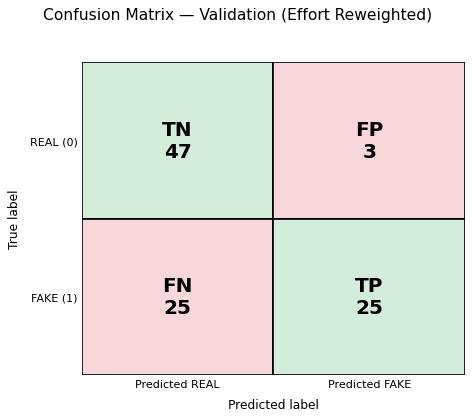

In [ ]:
# ── Confusion Matrix: Validation only — report best-AUC epoch from log ──
%matplotlib inline

import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, accuracy_score
from IPython.display import Image, display

LOG_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/effort_reweight_train/log.txt"


def get_best_auc_epoch_from_log(path):
    all_entries = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in entry and "test_image-level AUC" in entry:
                all_entries.append(entry)

    if not all_entries:
        raise RuntimeError(f"No valid validation AUC entries found in {path}")

    # Use only last run if log contains restarted runs
    runs = []
    current_run = []
    prev_epoch = -1

    for entry in all_entries:
        ep = int(entry["epoch"])

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(entry)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    last_run = runs[-1]

    best_entry = max(last_run, key=lambda e: float(e["test_image-level AUC"]))

    best_epoch = int(best_entry["epoch"]) + 1  # display as 1-based epoch
    best_auc = float(best_entry["test_image-level AUC"])
    best_f1 = float(best_entry.get("test_image-level F1", np.nan))

    return best_epoch, best_auc, best_f1


def compute_metrics(res):
    y_true = np.array([int(r["true_label"]) for r in res])
    y_pred = np.array([int(r["pred"]) for r in res])

    # Use confidence if available; otherwise score
    if "confidence" in res[0]:
        y_score = np.array([float(r["confidence"]) for r in res])
    elif "score" in res[0]:
        y_score = np.array([float(r["score"]) for r in res])
    else:
        y_score = y_pred.astype(float)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return TN, FP, FN, TP, acc, precision, recall, f1, auc


def draw_cm(ax, TN, FP, FN, TP, title):
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    cell_values = [[TN, FP], [FN, TP]]
    cell_colors = [["#d4edda", "#f8d7da"],
                   ["#f8d7da", "#d4edda"]]

    for i in range(2):
        for j in range(2):
            ax.add_patch(
                plt.Rectangle(
                    (j, 1 - i), 1, 1,
                    facecolor=cell_colors[i][j],
                    edgecolor="black",
                    linewidth=1.5
                )
            )
            ax.text(
                j + 0.5, 1 - i + 0.5,
                f"{cell_labels[i][j]}\n{cell_values[i][j]}",
                ha="center",
                va="center",
                fontsize=18,
                fontweight="bold",
                color="black"
            )

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)

    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([1.5, 0.5])

    ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=10)
    ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=10)

    ax.set_xlabel("Predicted label", fontsize=11, labelpad=8)
    ax.set_ylabel("True label", fontsize=11, labelpad=8)

    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=11, pad=14)


# Safety check
if len(results) == 0:
    raise RuntimeError("Validation results is empty.")

# Best logged validation epoch by AUC
best_epoch, best_log_auc, best_log_f1 = get_best_auc_epoch_from_log(LOG_PATH)

# Compute metrics from current results
TN, FP, FN, TP, acc, prec, rec, f1, auc = compute_metrics(results)

print(f"{'═'*60}")
print("  Validation Metrics")
print(f"{'═'*60}")
print(f"  Best epoch selected by validation AUC: {best_epoch}")
print(f"  Logged AUC at best epoch:             {best_log_auc:.4f}")
print(f"  Logged F1 at best-AUC epoch:          {best_log_f1:.4f}")
print(f"  Accuracy: {acc:.4f}")
print(f"{'─'*60}")
print(f"  TP (correct fake): {TP}")
print(f"  TN (correct real): {TN}")
print(f"  FP (false alarm):  {FP}")
print(f"  FN (missed fake):  {FN}")
print(f"{'═'*60}")

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

draw_cm(
    ax,
    TN, FP, FN, TP,
    f""
)

plt.suptitle("Confusion Matrix — Validation (Effort Reweighted)", fontsize=14, y=1.04)
plt.tight_layout()

plt.savefig(
    "confusion_matrix_val_effort_reweighted.jpg",
    dpi=80,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.close(fig)

display(Image("confusion_matrix_val_effort_reweighted.jpg"))

In [ ]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort Loss Train.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [ ]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort Loss Train.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Effort Loss Train.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 724446 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Effort Loss Train.html
Done — check your Drive for the .html file
